# Lab 18: Box Plots - Data Visualization
## IBM Data Analytics Capstone Project
### Objective: Visualize distributions, relationships, compositions and comparisons using box plots

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import numpy as np

# Load dataset and create SQLite database
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv')
conn = sqlite3.connect('survey-data.sqlite')
df.to_sql('main', conn, if_exists='replace', index=False)

print("Dataset loaded and SQLite database created!")
print("Shape:", df.shape)

Dataset loaded and SQLite database created!
Shape: (65437, 114)


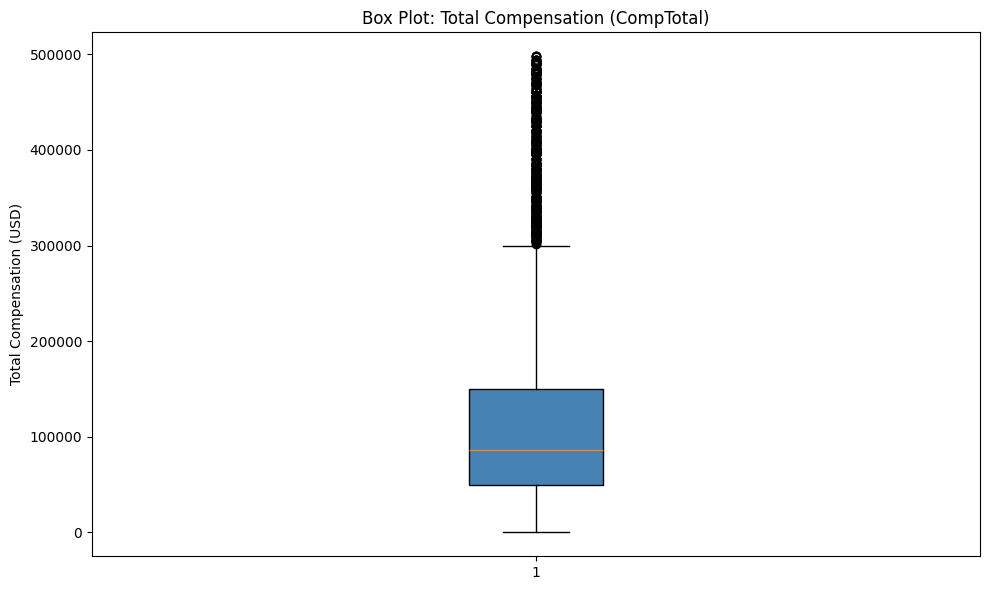

CompTotal box plot saved!
count     27533.000000
mean     112512.483311
std       90977.546703
min           0.000000
25%       50000.000000
50%       86000.000000
75%      150000.000000
max      498000.000000
Name: CompTotal, dtype: float64


In [2]:
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL AND CompTotal < 500000"
df_comp = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))
plt.boxplot(df_comp['CompTotal'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black'))
plt.title('Box Plot: Total Compensation (CompTotal)')
plt.ylabel('Total Compensation (USD)')
plt.tight_layout()
plt.savefig('boxplot_comptotal.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompTotal box plot saved!")
print(df_comp['CompTotal'].describe())

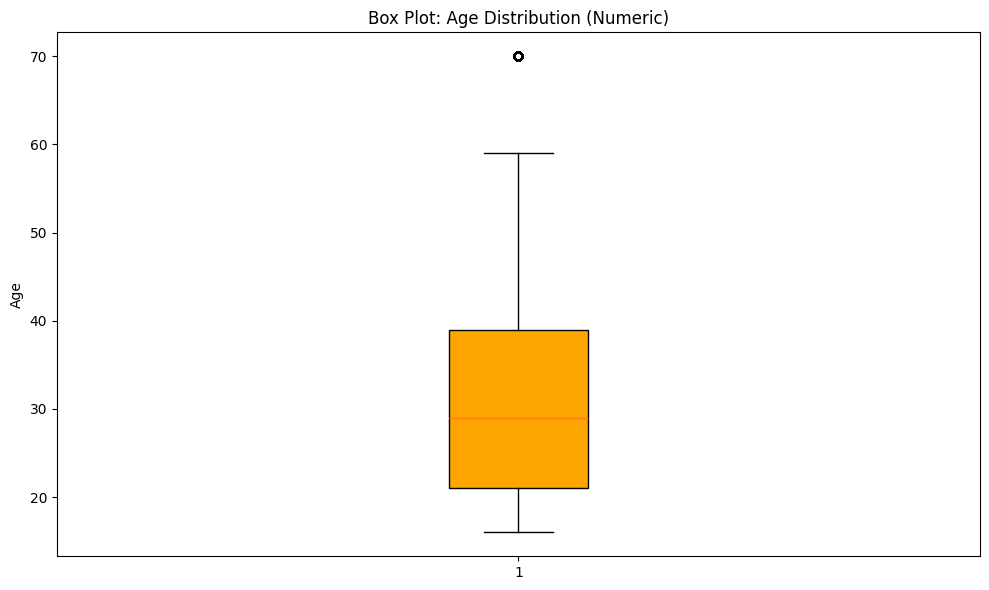

Age box plot saved!
count    65115.000000
mean        32.641772
std         11.140749
min         16.000000
25%         21.000000
50%         29.000000
75%         39.000000
max         70.000000
Name: Age_Numeric, dtype: float64


In [3]:
age_mapping = {
    'Under 18 years old': 16, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 70
}
QUERY = "SELECT Age FROM main WHERE Age IS NOT NULL AND Age != 'Prefer not to say'"
df_age = pd.read_sql_query(QUERY, conn)
df_age['Age_Numeric'] = df_age['Age'].map(age_mapping)

plt.figure(figsize=(10, 6))
plt.boxplot(df_age['Age_Numeric'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='orange', color='black'))
plt.title('Box Plot: Age Distribution (Numeric)')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('boxplot_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Age box plot saved!")
print(df_age['Age_Numeric'].describe())

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89075/1865261126.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_age, labels=['18-24', '25-34', '35-44', '45-54'],


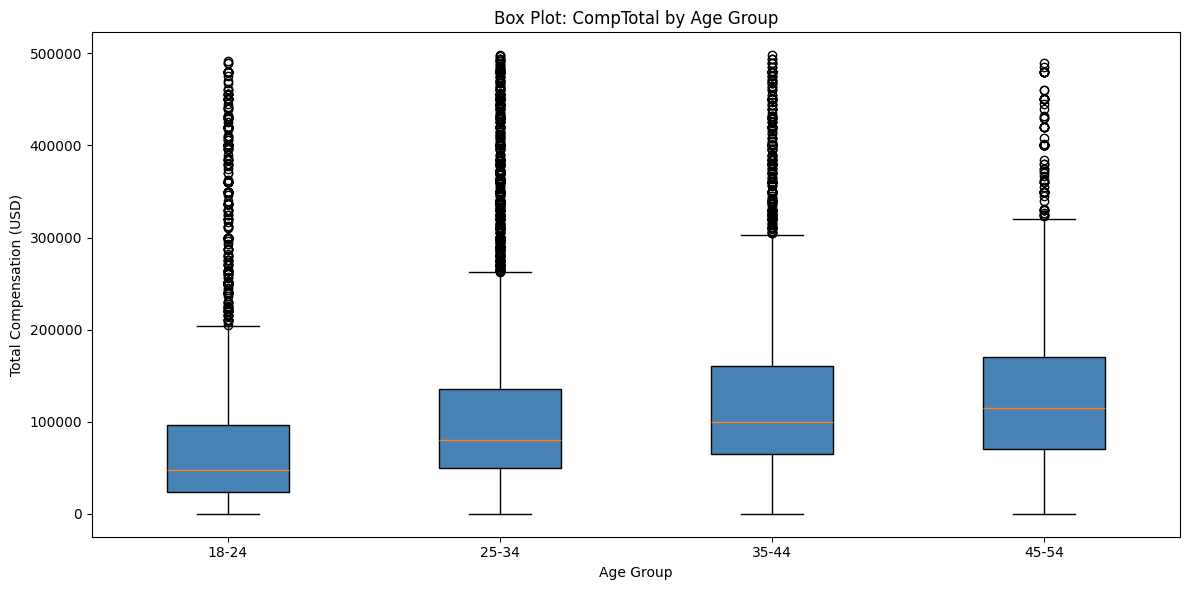

CompTotal by age group saved!


In [4]:
# CompTotal grouped by age groups
age_groups = ['18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old']
data_by_age = []

for age in age_groups:
    QUERY = f"""
    SELECT CompTotal FROM main 
    WHERE Age = '{age}' 
    AND CompTotal IS NOT NULL 
    AND CompTotal < 500000
    """
    data = pd.read_sql_query(QUERY, conn)['CompTotal'].dropna().tolist()
    data_by_age.append(data)

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_age, labels=['18-24', '25-34', '35-44', '45-54'],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black'))
plt.title('Box Plot: CompTotal by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation (USD)')
plt.tight_layout()
plt.savefig('boxplot_comp_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompTotal by age group saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89075/2047592367.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_sat, labels=[str(s) for s in top_scores],


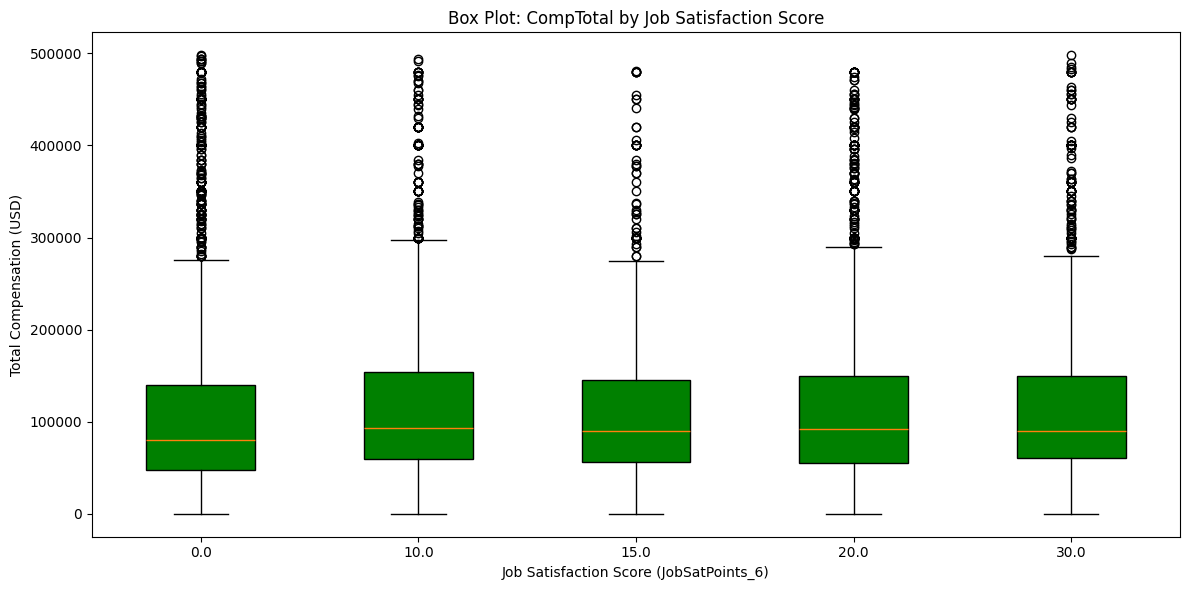

CompTotal by job satisfaction saved!


In [5]:
# CompTotal grouped by JobSatPoints_6
QUERY = """
SELECT CompTotal, JobSatPoints_6 FROM main
WHERE CompTotal IS NOT NULL 
AND CompTotal < 500000
AND JobSatPoints_6 IS NOT NULL
"""
df_jobsat = pd.read_sql_query(QUERY, conn)
top_scores = sorted(df_jobsat['JobSatPoints_6'].value_counts().head(5).index.tolist())

data_by_sat = []
for score in top_scores:
    data = df_jobsat[df_jobsat['JobSatPoints_6'] == score]['CompTotal'].tolist()
    data_by_sat.append(data)

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_sat, labels=[str(s) for s in top_scores],
            patch_artist=True,
            boxprops=dict(facecolor='green', color='black'))
plt.title('Box Plot: CompTotal by Job Satisfaction Score')
plt.xlabel('Job Satisfaction Score (JobSatPoints_6)')
plt.ylabel('Total Compensation (USD)')
plt.tight_layout()
plt.savefig('boxplot_comp_by_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompTotal by job satisfaction saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89075/2006691300.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_dev, labels=[d[:20] for d in top5_dev],


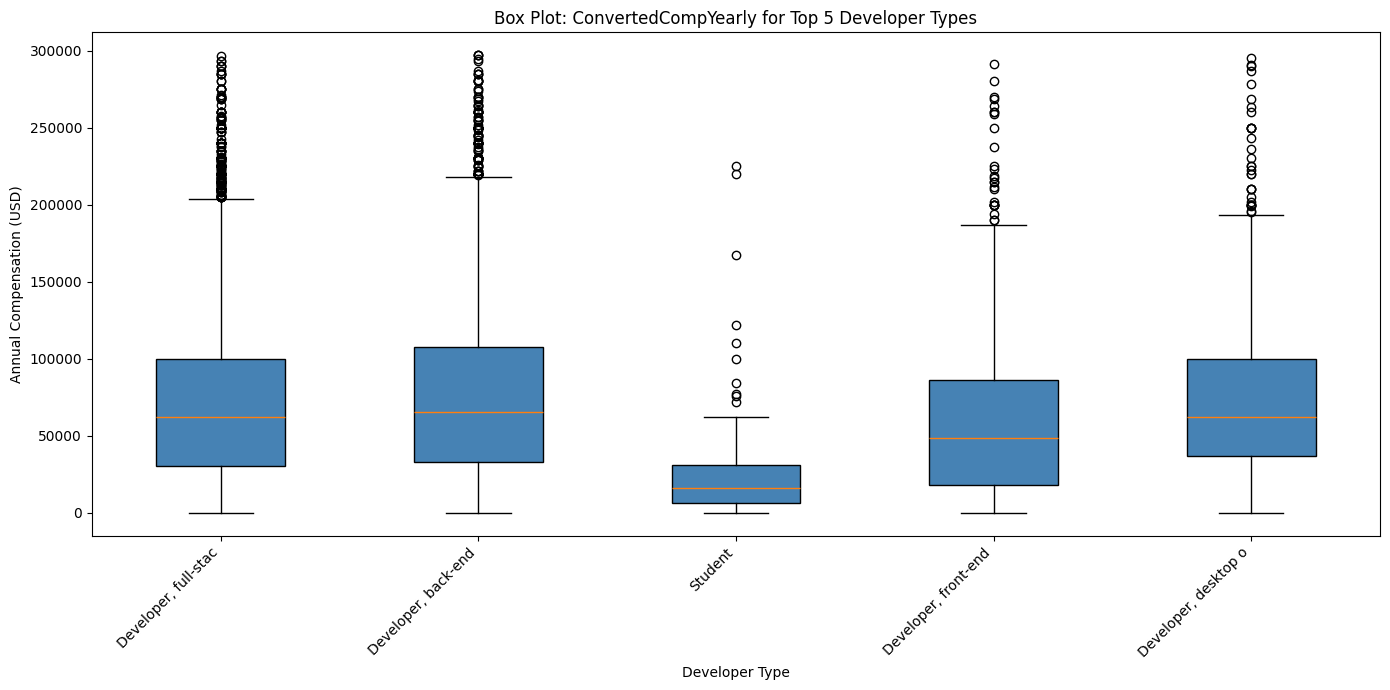

CompYearly by developer type saved!


In [6]:
# Top 5 developer types
QUERY = "SELECT DevType FROM main WHERE DevType IS NOT NULL"
df_dev = pd.read_sql_query(QUERY, conn)
dev_series = df_dev['DevType'].str.split(';').explode()
top5_dev = dev_series.value_counts().head(5).index.tolist()

data_by_dev = []
for dev in top5_dev:
    QUERY = f"""
    SELECT ConvertedCompYearly FROM main
    WHERE DevType LIKE '%{dev}%'
    AND ConvertedCompYearly IS NOT NULL
    AND ConvertedCompYearly < 300000
    """
    data = pd.read_sql_query(QUERY, conn)['ConvertedCompYearly'].tolist()
    data_by_dev.append(data)

plt.figure(figsize=(14, 7))
plt.boxplot(data_by_dev, labels=[d[:20] for d in top5_dev],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black'))
plt.title('Box Plot: ConvertedCompYearly for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('Annual Compensation (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('boxplot_comp_devtype.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompYearly by developer type saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89075/2560999683.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_country, labels=[c[:20] for c in top5_countries],


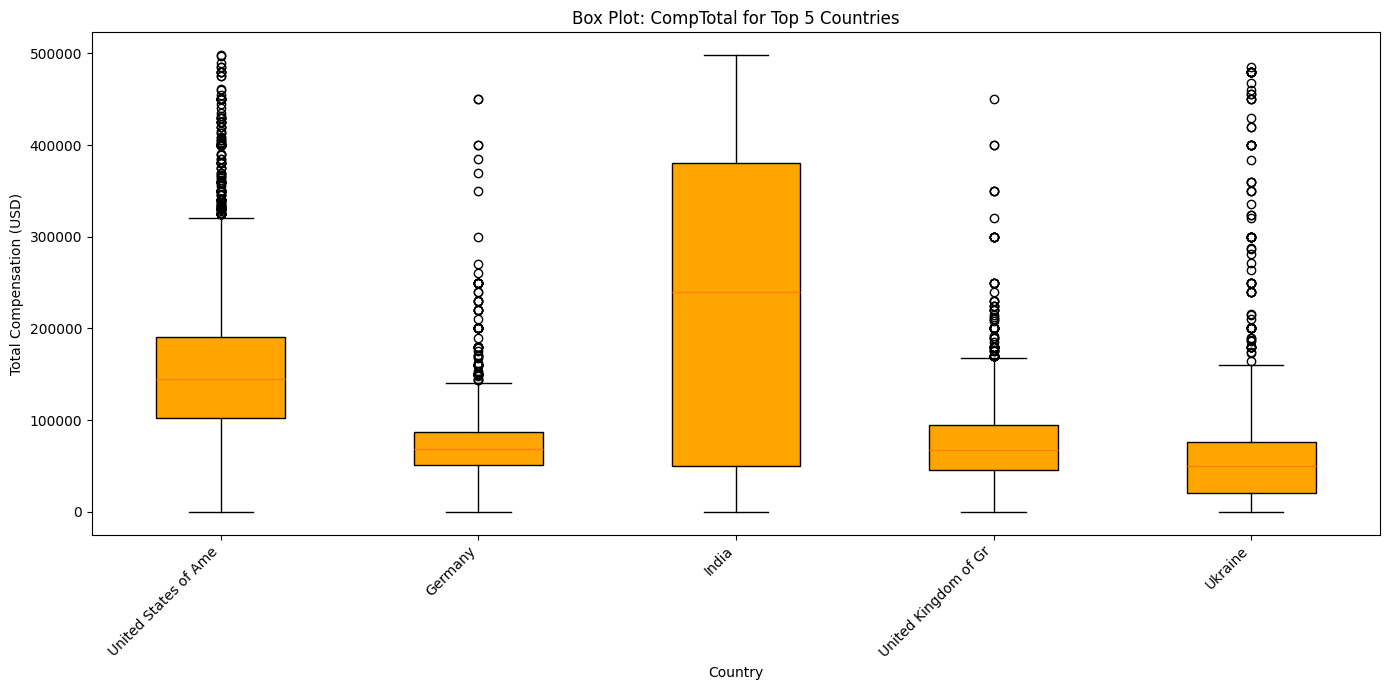

CompTotal by country saved!


In [7]:
# Top 5 countries
QUERY = """
SELECT Country, COUNT(*) as count FROM main 
WHERE Country IS NOT NULL 
GROUP BY Country ORDER BY count DESC LIMIT 5
"""
top5_countries = pd.read_sql_query(QUERY, conn)['Country'].tolist()

data_by_country = []
for country in top5_countries:
    QUERY = f"""
    SELECT CompTotal FROM main
    WHERE Country = '{country}'
    AND CompTotal IS NOT NULL
    AND CompTotal < 500000
    """
    data = pd.read_sql_query(QUERY, conn)['CompTotal'].tolist()
    data_by_country.append(data)

plt.figure(figsize=(14, 7))
plt.boxplot(data_by_country, labels=[c[:20] for c in top5_countries],
            patch_artist=True,
            boxprops=dict(facecolor='orange', color='black'))
plt.title('Box Plot: CompTotal for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Total Compensation (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('boxplot_comp_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompTotal by country saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89075/3684336022.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_emp, labels=[e[:25] for e in top4_emp],


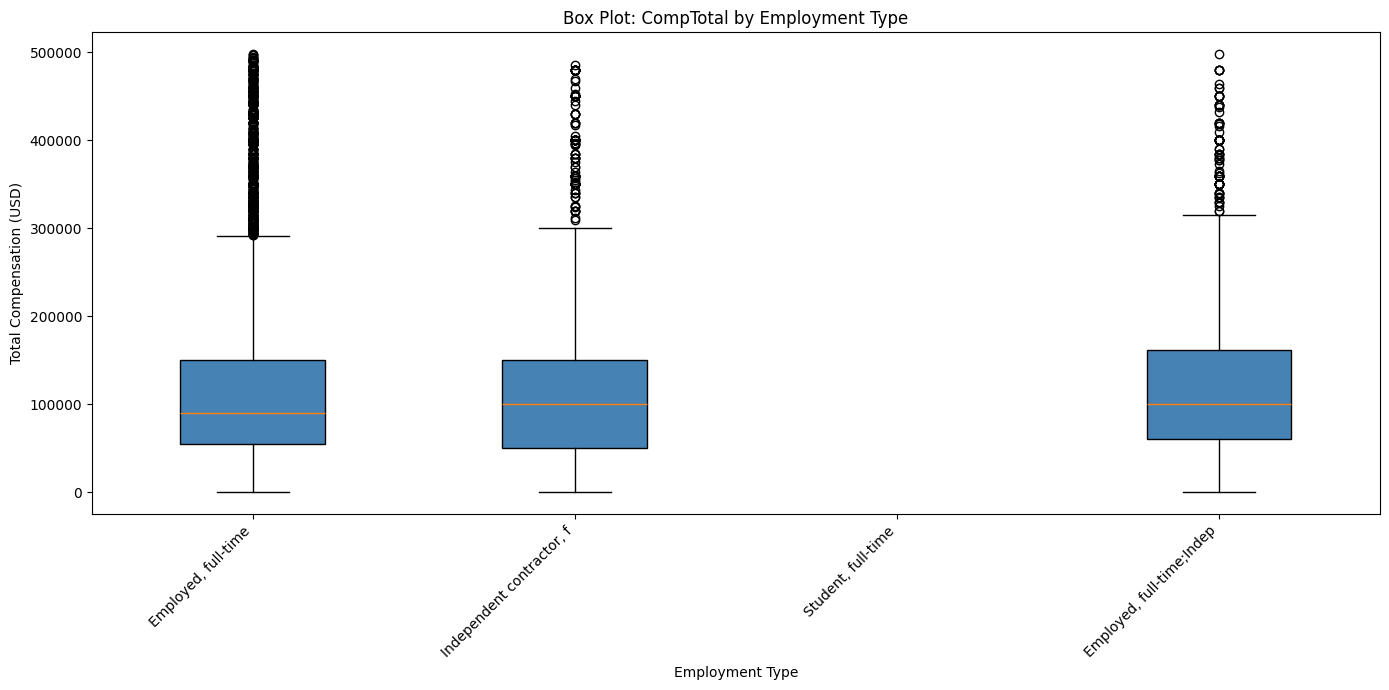

CompTotal by employment type saved!


In [8]:
# Top 4 employment types
QUERY = """
SELECT Employment, COUNT(*) as count FROM main
WHERE Employment IS NOT NULL
GROUP BY Employment ORDER BY count DESC LIMIT 4
"""
top4_emp = pd.read_sql_query(QUERY, conn)['Employment'].tolist()

data_by_emp = []
for emp in top4_emp:
    QUERY = f"""
    SELECT CompTotal FROM main
    WHERE Employment = '{emp}'
    AND CompTotal IS NOT NULL
    AND CompTotal < 500000
    """
    data = pd.read_sql_query(QUERY, conn)['CompTotal'].tolist()
    data_by_emp.append(data)

plt.figure(figsize=(14, 7))
plt.boxplot(data_by_emp, labels=[e[:25] for e in top4_emp],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black'))
plt.title('Box Plot: CompTotal by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('boxplot_comp_employment.png', dpi=150, bbox_inches='tight')
plt.show()
print("CompTotal by employment type saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_89075/961786763.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_score, labels=[str(int(s)) for s in top_scores],


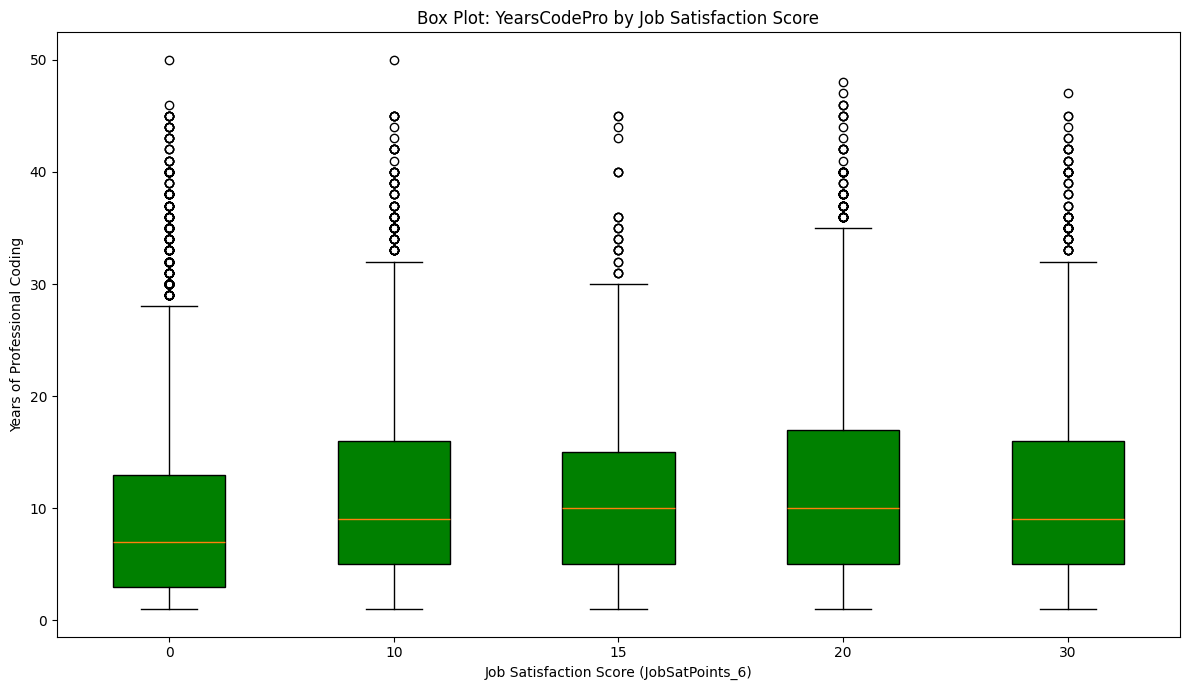

YearsCodePro by job satisfaction saved!
Database connection closed!


In [9]:
# YearsCodePro grouped by JobSatPoints_6
QUERY = """
SELECT CAST(YearsCodePro AS FLOAT) as YearsCodePro, JobSatPoints_6 
FROM main
WHERE YearsCodePro IS NOT NULL
AND YearsCodePro NOT LIKE '%Less%'
AND YearsCodePro NOT LIKE '%More%'
AND JobSatPoints_6 IS NOT NULL
"""
df_exp = pd.read_sql_query(QUERY, conn)
top_scores = sorted(df_exp['JobSatPoints_6'].value_counts().head(5).index.tolist())

data_by_score = []
for score in top_scores:
    data = df_exp[df_exp['JobSatPoints_6']==score]['YearsCodePro'].dropna().tolist()
    data_by_score.append(data)

plt.figure(figsize=(12, 7))
plt.boxplot(data_by_score, labels=[str(int(s)) for s in top_scores],
            patch_artist=True,
            boxprops=dict(facecolor='green', color='black'))
plt.title('Box Plot: YearsCodePro by Job Satisfaction Score')
plt.xlabel('Job Satisfaction Score (JobSatPoints_6)')
plt.ylabel('Years of Professional Coding')
plt.tight_layout()
plt.savefig('boxplot_years_jobsat.png', dpi=150, bbox_inches='tight')
plt.show()

conn.close()
print("YearsCodePro by job satisfaction saved!")
print("Database connection closed!")